In [2]:
import pandas as pd
import re
from pathlib import Path
import numpy as np
import pdb
import matplotlib.pyplot as plt

In [56]:
def parse_date(col_name):
    # Case 1: iYYYY_ddd-ddd_slie.tif
    m1 = re.match(r"i(\d{4})_(\d{3})-(\d{3})_slie\.tif", col_name)
    if m1:
        year, d1, d2 = map(int, m1.groups())
        day = (d1 + d2) // 2
        return pd.to_datetime(f"{year}-{day}", format="%Y-%j", errors="coerce")
    
    # Case 2: rYYYYMMDD_dailyslie.tif (and variants)
    m2 = re.match(r"[rc](\d{8})_dailyslie.*\.tif", col_name)
    if m2:
        datestr = m2.group(1)  # YYYYMMDD
        return pd.to_datetime(datestr, format="%Y%m%d", errors="coerce")
    
    return None

# --- Function to process a CSV file ---
def process_csv(file_path):
    df = pd.read_csv(file_path)
    df = df.drop(df.columns[0], axis=1)
    df = df.rename(columns={df.columns[0]: "coast_vector"})
    date_map = {col: parse_date(col) for col in df.columns[1:]}
    date_map = {k: v for k, v in date_map.items() if v is not None}
    df = df[["coast_vector"] + list(date_map.keys())]
    df_long = df.melt(id_vars="coast_vector", var_name="file", value_name="value")
    df_long["date"] = df_long["file"].map(date_map)
    df_long = df_long.drop(columns="file")
    df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
    df_long = df_long[df_long["date"].dt.year.between(2017, 2021)]
    df_long["year_month"] = df_long["date"].dt.to_period("M")
    return df_long

# --- Function to compute climatology for a pair of files ---
def compute_monthly_climatology(df_a, df_b, region_label, offset=0):
    merged = pd.merge(
        df_a, df_b, 
        on=["coast_vector", "year_month"], 
        suffixes=("_file1", "_file2"),
        how="inner"
    )
    merged["difference"] = merged["value_file1"] - merged["value_file2"]
    merged["date"] = merged["year_month"].dt.to_timestamp()
    merged["month"] = merged["date"].dt.month
    monthly_clim = (
        merged.groupby(["coast_vector", "month"])["difference"]
        .mean()
        .reset_index()
    )
    # Apply offset to coast_vector IDs
    monthly_clim["coast_vector"] = monthly_clim["coast_vector"] + offset
    diff_by_month = monthly_clim.pivot(
        index="coast_vector", columns="month", values="difference"
    )
    diff_by_month.columns = [
        pd.to_datetime(str(m), format="%m").strftime("%B")
        for m in diff_by_month.columns
    ]
    diff_by_month["region"] = region_label
    return diff_by_month


In [57]:
# --- Load coast vector -> region number mapping ---
map_beau = pd.read_csv("D:/MyDrive/EM2025_2025/ConfigData/Beaufort/cvecs_Beaufort_withsubregs.csv")  # contains Vec, regnum
map_chuk = pd.read_csv("D:/MyDrive/EM2025_2025/ConfigData/Chukchi/cvecs_Chukchi_KotzAdjust_withsubregs.csv")

# Offset Beaufort vectors to align with diff_by_month
n_chuk = diff_by_month.query("region == 'Chukchi'").shape[0]
map_beau["Vec"] = map_beau["Vec"] + n_chuk

# Combine mappings
vec_to_reg = pd.concat([map_chuk, map_beau], ignore_index=True)

# Compute region bounds (min/max Vec per regnum)
region_bounds = vec_to_reg.groupby("SubRegName")["Vec"].agg(["min", "max"]).reset_index()
region_bounds["center"] = (region_bounds["min"] + region_bounds["max"]) / 2
region_bounds = region_bounds.sort_values("center").reset_index(drop=True)

In [58]:
region_bounds


,SubRegName,min,max,center
0,Northern Chukotka Peninsula,1,1492,746.5
1,Northern Seward Peninsula,1493,2718,2105.5
2,Outer Kotzebue Sound,2719,2946,2832.5
3,Cape Kruzenstern - Point Hope,2947,3779,3363.0
4,Point Hope - Cape Lisburne,3780,4322,4051.0
5,Cape Lisburne - Wainwright,4323,6331,5327.0
6,Inner Kotzebue Sound,6332,6956,6644.0
7,Wainwright - Barrow,6957,7433,7195.0
8,Barrow - Kaktovik,7434,8332,7883.0
9,Kaktovik - Herschel Island,8333,8661,8497.0


In [59]:
file1 = Path("D:/MyDrive/Stability/RawData/Monthly_Averages/MergedOutput_month_year/BOEM_GeoTIFFs/Chuk/AllSeasonsAnalysis2023/lfiw_all.csv")
file2 = Path("D:/MyDrive/EM2025_2025/Chuk/AllSeasonsAnalysis2023/lfiw_all.csv")
file3 = Path("D:/MyDrive/Stability/RawData/Monthly_Averages/MergedOutput_month_year/BOEM_GeoTIFFs/Beau/AllSeasonsAnalysis2023/lfiw_all.csv")
file4 = Path("D:/MyDrive/EM2025_2025/Beau/AllSeasonsAnalysis2023/lfiw_all.csv")

# --- Process CSVs ---
df1 = process_csv(file1)
df2 = process_csv(file2)
df3 = process_csv(file3)
df4 = process_csv(file4)

C:\Users\aeinhorn\AppData\Local\Temp\ipykernel_31860\2469656353.py:19: DtypeWarning: Columns (3083,3084,3085,3086,3087,3088,3089,3090,3091,3092,3093,3094,3095,3096,3097,3098,3099,3100,3101,3102,3103,3104,3105,3106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [60]:
# --- Compute differences ---
diff_chuk = compute_monthly_climatology(df1, df2, "Chukchi", offset=0)
n_chuk = diff_chuk.shape[0]  # number of coast vectors in Chukchi
diff_beau = compute_monthly_climatology(df3, df4, "Beaufort", offset=n_chuk)

# --- Merge results (Chukchi first, then Beaufort with shifted IDs) ---
diff_by_month = pd.concat([diff_chuk, diff_beau], axis=0)


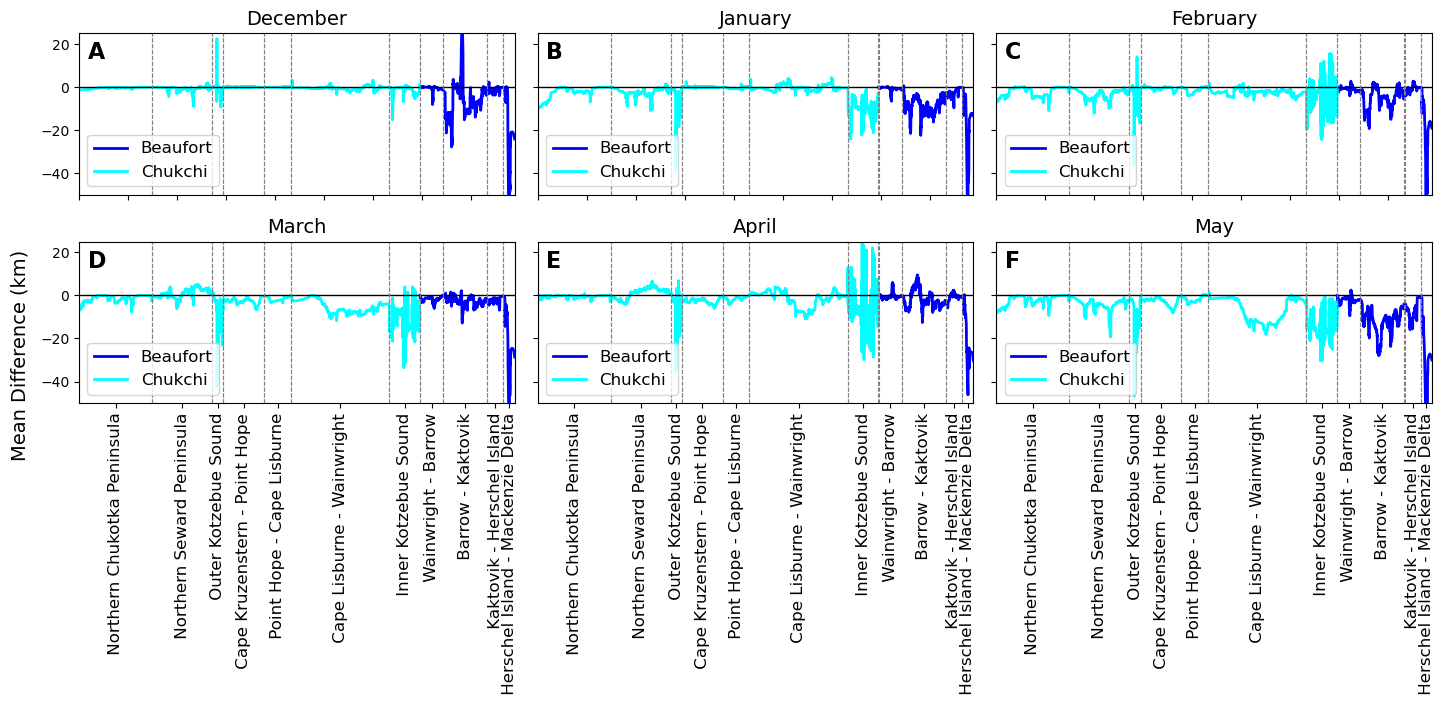

In [64]:
import string  # for letters A, B, C...

months_to_plot = ["December", "January", "February", "March", "April", "May"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

region_colors = {"Chukchi": "cyan", "Beaufort": "blue"}
axes_flat = axes.flat

letters = string.ascii_uppercase  # 'A', 'B', 'C', ...

for i, (ax, month) in enumerate(zip(axes_flat, months_to_plot)):
    if month in diff_by_month.columns:
        # Plot differences
        for region, group in diff_by_month.groupby("region"):
            ax.plot(
                group.index,
                group[month],
                label=region,
                color=region_colors.get(region, "black"),
                alpha=1,
                linewidth=2
            )
        
        # Zero line
        ax.axhline(0, color="k", linewidth=1)
        
        # Vertical lines at region boundaries
        for _, row in region_bounds.iterrows():
            ax.axvline(row["min"], color="gray", linestyle="--", linewidth=0.8)
            ax.axvline(row["max"], color="gray", linestyle="--", linewidth=0.8)
        
        # Only bottom row shows x-axis labels
        if i < 3:
            ax.set_xticklabels([])
        else:
            ax.set_xticks(region_bounds["center"])
            ax.set_xticklabels(region_bounds["SubRegName"], rotation=90, fontsize=12)
        
        ax.set_xlim([0, 8892])
        ax.set_ylim([-50, 25])
        ax.set_title(month, fontsize=14)
        ax.legend(loc='lower left', fontsize=12)
        
        # Add capital letter in top-left corner
        ax.text(
            0.02, 0.95, letters[i], transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top", ha="left"
        )

# Shared y-axis label
fig.text(0.04, 0.5, "Mean Difference (km)", va="center", rotation="vertical", fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
fig.savefig("D:/MyDrive/Stability/Figs/EM25_2_insar_monthlydiff.png", dpi=300, bbox_inches="tight")
plt.show()

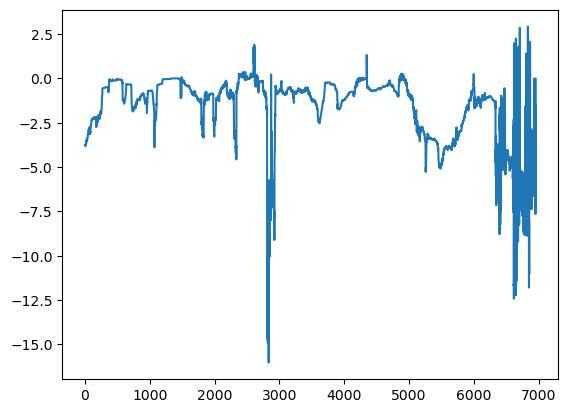

In [4]:
plt.plot(diff_pivot.mean(axis=1).values)

In [66]:
monthly_diff

year_month
2017-03-01   -2.592793
2017-04-01   -2.439460
2017-05-01   -8.258672
2017-06-01   -0.727444
2017-07-01    0.086501
2017-10-01    0.023735
2017-11-01   -0.200861
2017-12-01   -0.088863
2018-01-01    0.687208
2018-02-01   -0.713584
2018-03-01   -0.748085
2018-04-01   -0.956219
2018-05-01   -1.116324
2018-06-01   -0.176718
2018-07-01    0.053608
2018-10-01    0.073649
2018-11-01   -0.102475
2018-12-01   -0.552551
2019-01-01   -2.898429
2019-02-01   -1.671085
2019-03-01   -2.880736
2019-04-01   -1.337134
2019-05-01   -1.938487
2019-06-01    0.009114
2019-07-01    0.042999
2019-10-01    0.039002
2019-11-01   -0.110775
2019-12-01   -0.123929
2020-01-01   -4.489390
2020-02-01   -3.820648
2020-03-01   -8.908685
2020-04-01   -0.477629
2020-05-01   -8.870402
2020-06-01   -0.334460
2020-07-01    0.129773
2020-10-01    0.047757
2020-11-01   -0.038289
2020-12-01   -1.117573
2021-01-01   -2.604926
2021-02-01   -3.718896
2021-03-01   -3.293432
2021-04-01   -2.549353
2021-05-01   -7.240527


In [67]:
chuk = diff_by_month[diff_by_month["region"] == "Chukchi"].drop(columns="region")
beau = diff_by_month[diff_by_month["region"] == "Beaufort"].drop(columns="region")

# Compute monthly mean per coast vector (coast vectors remain rows, columns are months)
# This is effectively the same as averaging over coast vectors for each month
chuk_monthly_mean = chuk.mean(axis=0)
beau_monthly_mean = beau.mean(axis=0)

# Optional: keep only December–May
months_to_plot = ["December", "January", "February", "March", "April", "May"]
chuk_monthly_mean = chuk_monthly_mean[months_to_plot]
beau_monthly_mean = beau_monthly_mean[months_to_plot]

In [68]:
chuk_monthly_mean

December   -0.470729
January    -2.326385
February   -2.492908
March      -3.708423
April      -1.551959
May        -5.484882
dtype: float64

In [69]:
beau_monthly_mean

December    -5.152141
January     -6.384022
February    -5.118558
March       -4.692611
April       -3.418410
May        -10.696705
dtype: float64